In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [2]:
# Load Iris dataset

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Separate features and target

X = df.drop(columns=["species"])
y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

Features shape: (150, 4)
Target shape: (150,)

Feature columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
[0 1 2]


In [4]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


In [5]:
# Feature scaling for KNN

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
print(X_train_scaled[:5])

print("\nTesting data after scaling:")
print(X_test_scaled[:5])

Training data after scaling:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]

Testing data after scaling:
[[-1.72156775 -0.10821272 -1.40250384 -1.32327558]
 [ 0.30848902 -0.10821272  0.64163131  0.78343181]
 [-1.12449223 -1.45154306 -0.2668732  -0.26992188]
 [-1.00507713 -1.67543145 -0.2668732  -0.26992188]
 [-1.72156775  0.33956406 -1.40250384 -1.32327558]]


In [6]:
# Tune KNN using different values of n_neighbors

k_values = [1, 3, 5, 7, 9, 11, 13, 15]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    knn_accuracies.append(accuracy)

print("KNN Hyperparameter Tuning Results:")

for k, accuracy in zip(k_values, knn_accuracies):
    print(f"K = {k}: Accuracy = {accuracy * 100:.2f}%")

KNN Hyperparameter Tuning Results:
K = 1: Accuracy = 96.67%
K = 3: Accuracy = 93.33%
K = 5: Accuracy = 93.33%
K = 7: Accuracy = 96.67%
K = 9: Accuracy = 96.67%
K = 11: Accuracy = 96.67%
K = 13: Accuracy = 96.67%
K = 15: Accuracy = 96.67%


In [7]:
# Find the best K value

best_index = knn_accuracies.index(max(knn_accuracies))

best_k = k_values[best_index]
best_accuracy = knn_accuracies[best_index]

print("Best K value:", best_k)
print(f"Best KNN Accuracy: {best_accuracy * 100:.2f}%")

Best K value: 1
Best KNN Accuracy: 96.67%


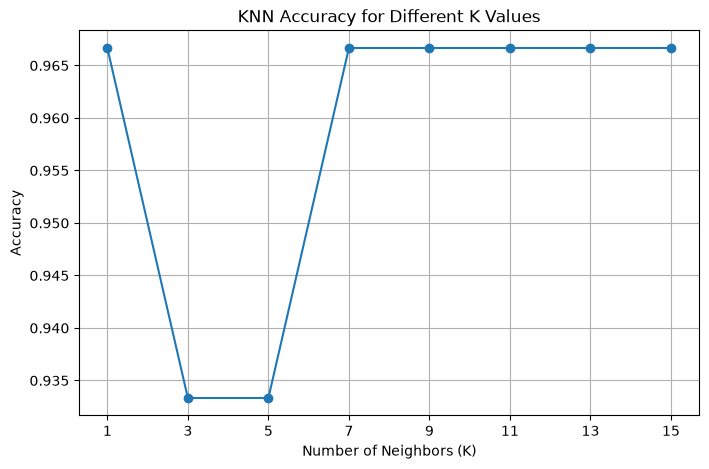

In [8]:
# Visualize KNN tuning results

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    knn_accuracies,
    marker="o"
)

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [9]:
# Tune Decision Tree using different max_depth values

depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
dt_accuracies = []

for depth in depth_values:
    decision_tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    decision_tree.fit(X_train, y_train)

    y_pred = decision_tree.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    dt_accuracies.append(accuracy)

print("Decision Tree Hyperparameter Tuning Results:")

for depth, accuracy in zip(depth_values, dt_accuracies):
    print(f"Max Depth = {depth}: Accuracy = {accuracy * 100:.2f}%")

Decision Tree Hyperparameter Tuning Results:
Max Depth = 1: Accuracy = 66.67%
Max Depth = 2: Accuracy = 93.33%
Max Depth = 3: Accuracy = 96.67%
Max Depth = 4: Accuracy = 93.33%
Max Depth = 5: Accuracy = 93.33%
Max Depth = 6: Accuracy = 93.33%
Max Depth = 7: Accuracy = 93.33%
Max Depth = 8: Accuracy = 93.33%
Max Depth = 9: Accuracy = 93.33%
Max Depth = 10: Accuracy = 93.33%


In [10]:
# Find the best max_depth value

best_depth_index = dt_accuracies.index(max(dt_accuracies))

best_depth = depth_values[best_depth_index]
best_dt_accuracy = dt_accuracies[best_depth_index]

print("Best Max Depth:", best_depth)
print(f"Best Decision Tree Accuracy: {best_dt_accuracy * 100:.2f}%")

Best Max Depth: 3
Best Decision Tree Accuracy: 96.67%


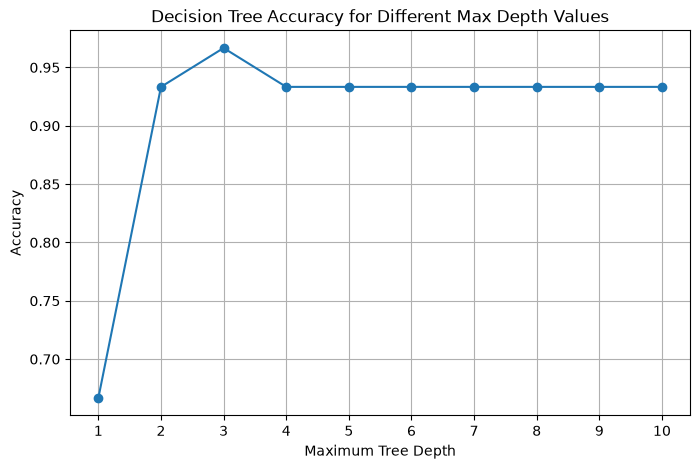

In [11]:
# Visualize Decision Tree tuning results

plt.figure(figsize=(8, 5))

plt.plot(
    depth_values,
    dt_accuracies,
    marker="o"
)

plt.title("Decision Tree Accuracy for Different Max Depth Values")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.xticks(depth_values)
plt.grid(True)

plt.show()

In [12]:
# Compare original and tuned model accuracies

original_knn_accuracy = 0.9333
original_dt_accuracy = 0.9333

print("Model Accuracy Comparison")
print("-" * 40)

print(f"Original KNN Accuracy: {original_knn_accuracy * 100:.2f}%")
print(f"Tuned KNN Accuracy: {best_accuracy * 100:.2f}%")

print()

print(f"Original Decision Tree Accuracy: {original_dt_accuracy * 100:.2f}%")
print(f"Tuned Decision Tree Accuracy: {best_dt_accuracy * 100:.2f}%")

Model Accuracy Comparison
----------------------------------------
Original KNN Accuracy: 93.33%
Tuned KNN Accuracy: 96.67%

Original Decision Tree Accuracy: 93.33%
Tuned Decision Tree Accuracy: 96.67%


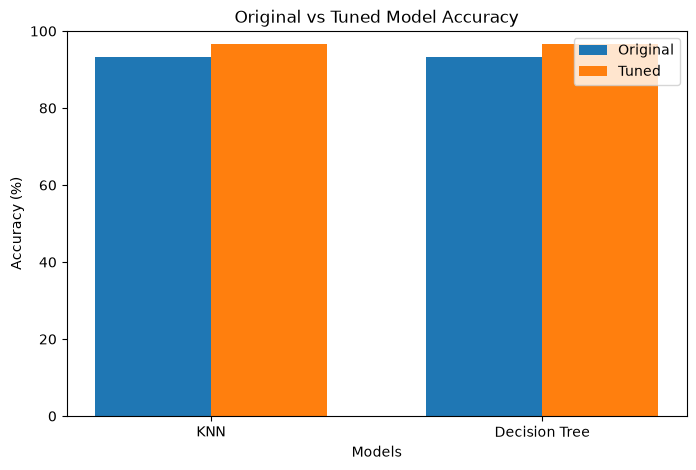

In [13]:
# Final comparison of original and tuned models

models = ["KNN", "Decision Tree"]

original_accuracies = [
    original_knn_accuracy * 100,
    original_dt_accuracy * 100
]

tuned_accuracies = [
    best_accuracy * 100,
    best_dt_accuracy * 100
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    original_accuracies,
    width,
    label="Original"
)

plt.bar(
    x + width / 2,
    tuned_accuracies,
    width,
    label="Tuned"
)

plt.title("Original vs Tuned Model Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.xticks(x, models)
plt.ylim(0, 100)
plt.legend()

plt.show()

In [14]:
# Analysis of hyperparameter tuning results

print("Hyperparameter Tuning Analysis")
print("-" * 40)

print(f"KNN: The best K value was {best_k}, achieving {best_accuracy * 100:.2f}% accuracy.")
print(f"Decision Tree: The best max_depth was {best_depth}, achieving {best_dt_accuracy * 100:.2f}% accuracy.")

print("\nOriginal KNN Accuracy: 93.33%")
print(f"Tuned KNN Accuracy: {best_accuracy * 100:.2f}%")

print("\nOriginal Decision Tree Accuracy: 93.33%")
print(f"Tuned Decision Tree Accuracy: {best_dt_accuracy * 100:.2f}%")

print("\nBoth models improved after hyperparameter tuning.")

Hyperparameter Tuning Analysis
----------------------------------------
KNN: The best K value was 1, achieving 96.67% accuracy.
Decision Tree: The best max_depth was 3, achieving 96.67% accuracy.

Original KNN Accuracy: 93.33%
Tuned KNN Accuracy: 96.67%

Original Decision Tree Accuracy: 93.33%
Tuned Decision Tree Accuracy: 96.67%

Both models improved after hyperparameter tuning.


In [15]:
# Final conclusion

print("Conclusion")
print("-" * 40)

print(
    "In Week 6–7, hyperparameter tuning was performed on "
    "KNN and Decision Tree models using the Iris dataset."
)

print(
    f"The best KNN model used K = {best_k} and achieved "
    f"{best_accuracy * 100:.2f}% accuracy."
)

print(
    f"The best Decision Tree model used max_depth = {best_depth} "
    f"and achieved {best_dt_accuracy * 100:.2f}% accuracy."
)

print(
    "Both tuned models improved from the original accuracy of "
    "93.33% to 96.67% on the test dataset."
)

print(
    "This experiment helped in understanding how hyperparameter "
    "selection can affect machine learning model performance."
)

Conclusion
----------------------------------------
In Week 6–7, hyperparameter tuning was performed on KNN and Decision Tree models using the Iris dataset.
The best KNN model used K = 1 and achieved 96.67% accuracy.
The best Decision Tree model used max_depth = 3 and achieved 96.67% accuracy.
Both tuned models improved from the original accuracy of 93.33% to 96.67% on the test dataset.
This experiment helped in understanding how hyperparameter selection can affect machine learning model performance.
